# Módulo 3 — Detecção de Anomalias em Sinais Vitais
**Dataset:** MIMIC-III Clinical Database Demo (PhysioNet)
**Técnica:** Isolation Forest (não supervisionado)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

DATA_PATH        = '../data/raw/'
CHARTEVENTS_PATH = DATA_PATH + 'CHARTEVENTS.csv'
PATIENTS_PATH    = DATA_PATH + 'PATIENTS.csv'
ICUSTAYS_PATH    = DATA_PATH + 'ICUSTAYS.csv'
print('OK')

OK


In [12]:
# Colunas em minúsculo conforme o arquivo real
cols = ['subject_id', 'hadm_id', 'icustay_id', 'itemid', 'charttime', 'valuenum', 'valueuom']
chart = pd.read_csv(CHARTEVENTS_PATH, usecols=cols)
print(f'CHARTEVENTS: {chart.shape[0]:,} registros')
chart.head()

CHARTEVENTS: 758,355 registros


,subject_id,hadm_id,icustay_id,itemid,charttime,valuenum,valueuom
0,40124,126179,279554.0,223761,2130-02-04 04:00:00,95.9,?F
1,40124,126179,279554.0,224695,2130-02-04 04:25:00,2222221.7,cmH2O
2,40124,126179,279554.0,220210,2130-02-04 04:30:00,15.0,insp/min
3,40124,126179,279554.0,220045,2130-02-04 04:32:00,94.0,bpm
4,40124,126179,279554.0,220179,2130-02-04 04:32:00,163.0,mmHg


In [13]:
patients = pd.read_csv(PATIENTS_PATH)
icustays = pd.read_csv(ICUSTAYS_PATH)
print(f'Pacientes: {patients.shape[0]}')
print(f'Internações UTI: {icustays.shape[0]}')
patients.head()

Pacientes: 100
Internações UTI: 136


,row_id,subject_id,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,9467,10006,F,2094-03-05 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,1
1,9472,10011,F,2090-06-05 00:00:00,2126-08-28 00:00:00,2126-08-28 00:00:00,NaN,1
2,9474,10013,F,2038-09-03 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,1
3,9478,10017,F,2075-09-21 00:00:00,2152-09-12 00:00:00,NaN,2152-09-12 00:00:00,1
4,9479,10019,M,2114-06-20 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,1


In [14]:
VITALS_MAP = {
    211: 'heart_rate', 220045: 'heart_rate',
    51: 'systolic_bp', 220179: 'systolic_bp',
    8368: 'diastolic_bp', 220180: 'diastolic_bp',
    646: 'spo2', 220277: 'spo2',
    618: 'respiratory_rate', 220210: 'respiratory_rate',
    223761: 'temperature', 678: 'temperature',
}
vitals = chart[chart['itemid'].isin(VITALS_MAP.keys())].copy()
vitals['vital_name'] = vitals['itemid'].map(VITALS_MAP)
vitals['charttime'] = pd.to_datetime(vitals['charttime'])
vitals = vitals.dropna(subset=['valuenum'])
print(f'Registros de sinais vitais: {vitals.shape[0]:,}')
print(vitals['vital_name'].value_counts())

Registros de sinais vitais: 68,275
vital_name
heart_rate          15485
spo2                15300
respiratory_rate    15086
systolic_bp          9389
diastolic_bp         9383
temperature          3632
Name: count, dtype: int64


In [15]:
# Limpeza: remove valores zerados (artefatos de sensor)
# Nenhum sinal vital real pode ser zero em um paciente vivo
LIMITES_MINIMOS = {
    'heart_rate':       1,
    'systolic_bp':      1,
    'diastolic_bp':     1,
    'spo2':             1,
    'respiratory_rate': 1,
    'temperature':      30.0,  # abaixo de 30°C = hipotermia grave / artefato
}

antes = len(vitals)
for sinal, minimo in LIMITES_MINIMOS.items():
    mask = (vitals['vital_name'] == sinal) & (vitals['valuenum'] <= minimo)
    vitals = vitals[~mask]

depois = len(vitals)
print(f'Registros removidos (artefatos de sensor): {antes - depois:,}')
print(f'Registros restantes: {depois:,}')

Registros removidos (artefatos de sensor): 173
Registros restantes: 68,102


In [16]:
vitals_pivot = (
    vitals
    .groupby(['subject_id', 'charttime', 'vital_name'])['valuenum']
    .mean()
    .unstack('vital_name')
    .reset_index()
)
feature_cols = [c for c in vitals_pivot.columns if c not in ['subject_id', 'charttime']]
print(f'Shape: {vitals_pivot.shape}')
print('Sinais disponíveis:', feature_cols)
vitals_pivot.head()

Shape: (17358, 8)
Sinais disponíveis: ['diastolic_bp', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'temperature']


vital_name,subject_id,charttime,diastolic_bp,heart_rate,respiratory_rate,spo2,systolic_bp,temperature
0,10006,2164-10-23 22:40:00,NaN,104.0,25.0,98.0,NaN,99.599998
1,10006,2164-10-23 23:00:00,NaN,99.0,17.0,98.0,NaN,NaN
2,10006,2164-10-24 00:00:00,NaN,96.0,20.0,98.0,NaN,NaN
3,10006,2164-10-24 01:00:00,NaN,95.0,23.0,98.0,NaN,97.500000
4,10006,2164-10-24 02:00:00,NaN,92.0,91.0,97.0,NaN,NaN


Paciente 41976: 1294 registros


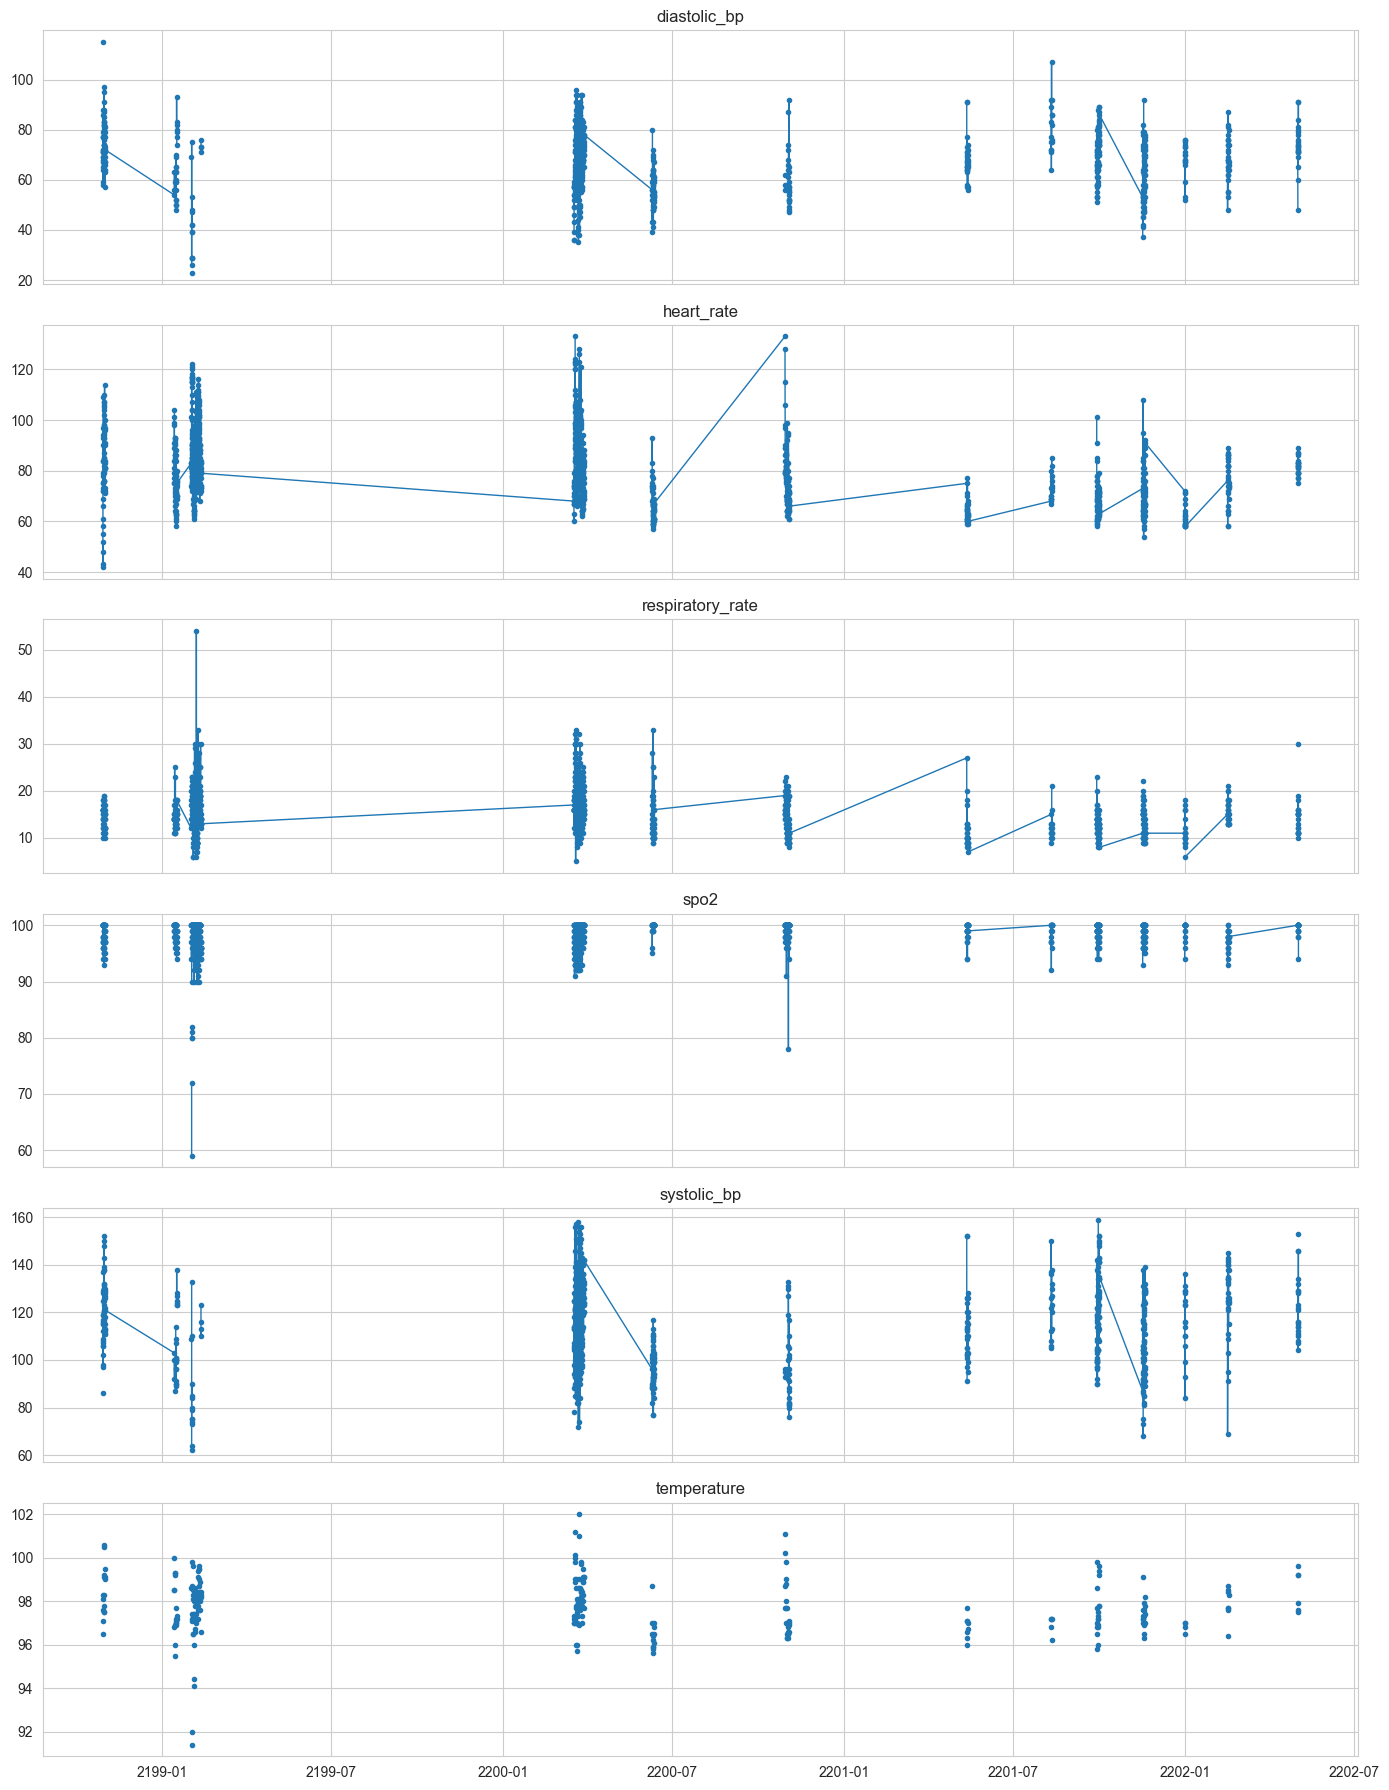

In [17]:
paciente_id = vitals_pivot['subject_id'].value_counts().index[0]
df_pac = vitals_pivot[vitals_pivot['subject_id'] == paciente_id].sort_values('charttime')
sinais_disponiveis = [c for c in feature_cols if df_pac[c].notna().sum() > 5]
print(f'Paciente {paciente_id}: {len(df_pac)} registros')

n = len(sinais_disponiveis)
fig, axes = plt.subplots(n, 1, figsize=(14, 3*n), sharex=True)
if n == 1: axes = [axes]
for ax, sinal in zip(axes, sinais_disponiveis):
    ax.plot(df_pac['charttime'], df_pac[sinal], marker='o', markersize=3, linewidth=1)
    ax.set_title(sinal)
plt.tight_layout()
plt.show()

In [18]:
df_model = vitals_pivot[feature_cols].dropna(thresh=2).fillna(vitals_pivot[feature_cols].median())
X = StandardScaler().fit_transform(df_model)
iso = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
preds = iso.fit_predict(X)
scores = iso.score_samples(X)

df_result = vitals_pivot.loc[df_model.index].copy()
df_result['anomaly'] = preds == -1
df_result['anomaly_score'] = scores
n_an = df_result['anomaly'].sum()
print(f'Anomalias detectadas: {n_an} ({n_an/len(df_result)*100:.1f}%)')

Anomalias detectadas: 813 (5.0%)


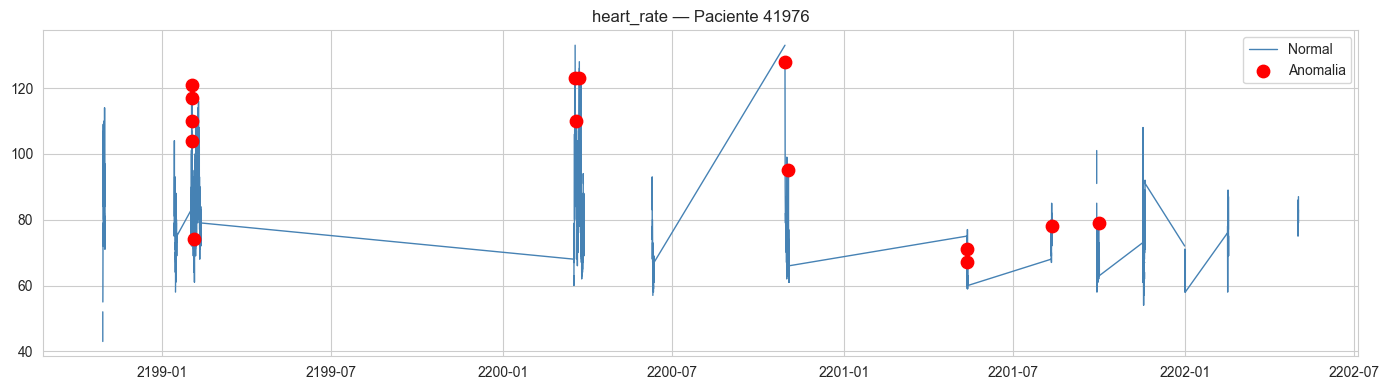

In [19]:
sinal_plot = 'heart_rate' if 'heart_rate' in feature_cols else sinais_disponiveis[0]
df_plot = df_result[df_result['subject_id'] == paciente_id].sort_values('charttime')
anomalas = df_plot[df_plot['anomaly']]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_plot['charttime'], df_plot[sinal_plot], color='steelblue', linewidth=1, label='Normal')
ax.scatter(anomalas['charttime'], anomalas[sinal_plot], color='red', s=80, zorder=5, label='Anomalia')
ax.set_title(f'{sinal_plot} — Paciente {paciente_id}')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
CLINICAL_RANGES = {
    'heart_rate': (60, 100), 'systolic_bp': (90, 140),
    'diastolic_bp': (60, 90), 'spo2': (95, 100),
    'respiratory_rate': (12, 20), 'temperature': (36.0, 37.5),
}
def severidade(row):
    fora = sum(1 for s, (mn, mx) in CLINICAL_RANGES.items()
               if s in row and pd.notna(row[s]) and (row[s] < mn or row[s] > mx))
    return 'CRÍTICA' if fora >= 3 else 'ALTA' if fora == 2 else 'MÉDIA' if fora == 1 else 'BAIXA'

anomalias = df_result[df_result['anomaly']].copy()
anomalias['severidade'] = anomalias.apply(severidade, axis=1)
print('=== RELATÓRIO DE ANOMALIAS ===')
print(anomalias['severidade'].value_counts())
anomalias.sort_values('anomaly_score').head(10)

=== RELATÓRIO DE ANOMALIAS ===
severidade
CRÍTICA    594
ALTA       199
MÉDIA       20
Name: count, dtype: int64


vital_name,subject_id,charttime,diastolic_bp,heart_rate,respiratory_rate,spo2,systolic_bp,temperature,anomaly,anomaly_score,severidade
9015,40310,2144-12-29 13:00:00,133.0,147.0,34.0,68.0,193.0,NaN,True,-0.746648,CRÍTICA
1848,10045,2129-11-30 23:15:00,34.0,96.0,56.0,49.0,64.0,NaN,True,-0.728576,CRÍTICA
1846,10045,2129-11-30 23:05:00,36.0,99.0,53.0,24.0,68.0,NaN,True,-0.723514,CRÍTICA
4223,10098,2170-12-03 15:50:00,20.0,50.0,NaN,7.0,37.0,NaN,True,-0.715882,CRÍTICA
1836,10045,2129-11-30 22:15:00,39.0,101.0,44.0,4.0,76.0,NaN,True,-0.715140,CRÍTICA
5883,10124,2192-05-15 18:25:00,33.0,31.0,NaN,50.0,42.0,NaN,True,-0.714205,CRÍTICA
401,10013,2125-10-07 12:10:00,26.0,46.0,11.0,66.0,52.0,NaN,True,-0.710138,CRÍTICA
1845,10045,2129-11-30 23:00:00,40.0,98.0,49.0,12.0,78.0,NaN,True,-0.706860,CRÍTICA
1840,10045,2129-11-30 22:35:00,41.0,100.0,47.0,53.0,80.0,NaN,True,-0.692543,CRÍTICA
1841,10045,2129-11-30 22:40:00,41.0,97.0,44.0,53.0,81.0,NaN,True,-0.688291,CRÍTICA
